# 6J (Japanese Yen) — MA crossover, Tradovate exchange

Mirrors `MES/step_2_run_full_backtest.ipynb`'s MA-crossover setup, applied to **Japanese Yen futures** (6J) instead of MES: real 1h OHLC pulled from this repo's Mongo/Timescale store (via the shared `data_aggregator.mongo_timescale_aggregator` module), whole-contract position sizing, tick-based slippage + per-contract fees, and a Tradeify-style EOD-trailing drawdown risk middleware.

**Strategy**: a single crossover -- the winner of the four-way indicator-family comparison (KAMA, EMA, HMA, DEMA, each fast-line paired against a plain SMA slow line) run in `6J/step_1_find_best_indicators_and_parameters.ipynb`, selected by a trade-level Sharpe lower bound rather than raw return (see that notebook's "Methodology" and "Final pick" cells for the full reasoning + honest caveats about how much confidence that pick actually supports). Only 2 indicators feed a single strategy here, run through the full event-driven engine: real order fills, margin, whole-contract sizing, and the drawdown middleware, none of which the vectorized notebook models. Same `DATE_FROM`/`DATE_TO` window as that notebook so the two are comparable. Results here will still differ from the vectorized numbers -- that's expected, not a bug, since whole-contract sizing/margin are modeled for real here instead of as a frictionless percentage-return approximation.

**Costs, now researched** (`PROP_FIRM_PLAN.md`, `OPTIMIZATION_RESEARCH_PLAN.md`): 6J tick_size=0.0000005 ($6.25/tick, CME spec) and a commission are set directly on `TRADOVATE_FUTURES["6J"]` in `exchange_config.py`. 6J commission: 6J is a full-size (not micro) contract; Tradeify's fee source gives standard-contract round-turn as ~$3.04-3.12 without naming 6J specifically -- this uses the ~$3.08 midpoint (-> $1.54/side), an approximation, not a confirmed exact number (see `PROP_FIRM_PLAN.md`). The drawdown middleware below uses Tradeify's real $50k-Growth-account number (4%, not this middleware's generic 5% default) and models the real lock-once-reached trail-freeze mechanic.

**Important finding #1, discovered running this cell**: 6J is a **full-size** contract (¥12,500,000/contract) whose notional (~$77-84k at recent JPY/USD rates) *exceeds the entire $50k account* -- at `weight=1.0` (100%) with **unleveraged** sizing (this system's historical default), `raw_volume = (50000 * 1.0) / notional < 1` every single time, so the position silently floors to **0 contracts for the entire backtest**. The strategy still logged 109 percent-based "trades" with a real profit factor (1.25), but none of it ever touched real account equity -- net_return/Sharpe/volatility/time-in-market all showed exactly 0. This is the same failure mode discovered in `combined.ipynb` for MES/MNQ at 1/3 weight, now showing up in a *solo, 100%-weight* run because 6J's own per-contract notional is simply too large for unleveraged sizing on this account size. **Fix applied below**: `leverage_aware_sizing=True, max_leverage=5` (same setting `combined.ipynb` uses) -- this is required for 6J to trade at all on a $50k account, not an optional enhancement.

**Important finding #2, discovered turning leverage on**: with real contracts now actually trading, closing a highly-levered position (routine every time the crossover reverses) hit a genuine pre-existing engine bug -- `Orders.validate_order_before_creating()` hardcoded `side=PositionSide.long` when computing required margin for *every* order, instead of deriving it from the order's actual side. A sell order closing a long was therefore evaluated as if it were opening a fresh new long of the same size (since `side == position.side` skipped the opposite-side margin-netting branch), demanding a second helping of margin instead of freeing the first -- raising `ValueError: Not enough USD` on any close tight enough on margin to expose it. This never surfaced before because typical (unleveraged) position sizing left enough free-margin headroom to absorb the miscount; leverage removed that slack. **Fixed in `exchange/order.py`** (both call sites), with a regression test
(`test_positions.py::TestClosingDoesNotReRequireMargin`) -- confirmed the rest of the
suite (186 tests, including all 4 golden tests) was unaffected by the fix.

**Result, real leveraged run**: the account actually **breached the 4% Tradeify
drawdown limit and halted** (`account_failed=True`) after only 13 of the strategy's
109 signaled trades -- max drawdown -5.93%, well past the trail. Combined with
step_1's already-weak standalone numbers (every indicator family showed a negative
`trade_sharpe_lb`), this is a strong signal that 6J's weak edge, once actually
leveraged enough to matter, is risky enough to blow this account on its own. Whether
its negative-correlation hedge value is still worth including at a much smaller
weight is exactly what `combined.ipynb`'s 3-of-6 selection should decide -- not
assumed here.

In [1]:
import json
import os

import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import MaCrossoverStrategy, StrategyDirection
from data_aggregator.mongo_timescale_aggregator import fetch_market_data

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/tradovate_ma_crossover/6J


In [2]:

# Instantiate markets class
market = Market()

# ALL INTERVALS SHOULD BE THE SAME!!
INTERVAL = 1
UNIT_OF_TIME = "hour"

DISPLAY_SYMBOL = "6J"       # bare symbol, as registered in Mongo `instruments`
SYMBOL = "6J/USD"           # backtester-internal symbol (asset/quote)
SOURCE = "ib"                # Interactive Brokers continuous futures contract
RESOLUTION = "1_hour"

# Same window as notebooks/vectorized_backtest_mes_tradovate.ipynb, for comparability.
DATE_FROM = "2019-10-01"
DATE_TO = "2026-06-01"

# Winner of the 4-indicator-family comparison in step_1 (weakest of the 6 instruments
# tested -- 3 of the 4 families had zero qualifying combos at all, see step_1's
# "Final pick" cell): DEMA(fast)/SMA(slow), long_len=22, short_len=14.
DEMA_FAST_LEN = 14
DEMA_SMA_SLOW = 22

ohlc = fetch_market_data(source=SOURCE, display_symbol=DISPLAY_SYMBOL, resolution=RESOLUTION)
ohlc = ohlc.loc[DATE_FROM:DATE_TO]

market.add_market(
    symbol=SYMBOL,
    df=ohlc
    )

# --- DEMA(fast)/SMA(slow) crossover indicators -- only 2, one per side of the crossover.
DEMA_INDICATOR_NAME = 'dema'
SMA_INDICATOR_NAME = 'sma'
market.add_indicator(
    symbol=SYMBOL,
    interval=INTERVAL,
    unit_of_time=UNIT_OF_TIME,
    indicator_name=f"{DEMA_INDICATOR_NAME}_{DEMA_FAST_LEN}",
    df=Indicators.dema(ohlc, length=DEMA_FAST_LEN)
)
market.add_indicator(
    symbol=SYMBOL,
    interval=INTERVAL,
    unit_of_time=UNIT_OF_TIME,
    indicator_name=f"{SMA_INDICATOR_NAME}_{DEMA_SMA_SLOW}",
    df=Indicators.sma(ohlc, DEMA_SMA_SLOW)
)

market.compile()

{Timestamp('2025-07-08 21:47:39.999000'): {'num': 0,
  'time_open': Timestamp('2025-07-08 20:47:40'),
  'time_close': Timestamp('2025-07-08 21:47:39.999000'),
  '6J/USD': {'open': 0.007104,
   'high': 0.007105,
   'low': 0.007102,
   'close': 0.0071035,
   'volume': 437.0,
   'indicators': {'dema_14': nan, 'sma_22': nan}}},
 Timestamp('2025-07-08 22:59:59.999000'): {'num': 1,
  'time_open': Timestamp('2025-07-08 22:00:00'),
  'time_close': Timestamp('2025-07-08 22:59:59.999000'),
  '6J/USD': {'open': 0.0071035,
   'high': 0.0071035,
   'low': 0.0070995,
   'close': 0.007101,
   'volume': 840.0,
   'indicators': {'dema_14': nan, 'sma_22': nan}}},
 Timestamp('2025-07-08 23:59:59.999000'): {'num': 2,
  'time_open': Timestamp('2025-07-08 23:00:00'),
  'time_close': Timestamp('2025-07-08 23:59:59.999000'),
  '6J/USD': {'open': 0.007101,
   'high': 0.007101,
   'low': 0.007087,
   'close': 0.0070875,
   'volume': 3702.0,
   'indicators': {'dema_14': nan, 'sma_22': nan}}},
 Timestamp('2025-07

In [3]:

# single DEMA(fast)/SMA(slow) crossover strategy, full weight -- see
# 6J/step_1_find_best_indicators_and_parameters.ipynb for how these parameters were picked.
portfolio = Portfolio(weighted_strategies=[
    WeightedStrategy(
        weight=1.0,
        strategy=MaCrossoverStrategy(
            key=f"DEMA_{DEMA_FAST_LEN}_SMA_{DEMA_SMA_SLOW}_6J",
            market=market,
            symbol=SYMBOL,
            direction=StrategyDirection.long,
            fast_indicator_key=f"{DEMA_INDICATOR_NAME}_{DEMA_FAST_LEN}",
            slow_indicator_key=f"{SMA_INDICATOR_NAME}_{DEMA_SMA_SLOW}",
            sl_percent=0.3,
            tp_percent=0.6,
            sl_enabled=True,
            tp_enabled=True,
        ),
    ),
], output_scale=1)

print("Portfolio is ready!")


Portfolio is ready!


In [4]:

# Tradovate per-symbol config: point value / tick size / min size-step / fees.
# 6J has a real tick_size and fee_per_contract_override set directly on
# TRADOVATE_FUTURES in exchange_config.py (see PROP_FIRM_PLAN.md for the research).
symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)

# instantiate exchange -- futures, point-value/tick-based math via symbol_config_provider
# (slippage/maker_fee/taker_fee below are unused once symbol_config_provider is set, but
# still required constructor args).
# leverage_aware_sizing=True: REQUIRED for 6J specifically -- its own per-contract
# notional (~$77-84k) exceeds the entire $50k account, so unleveraged sizing (this
# system's historical default) always floors to 0 contracts (see intro markdown for
# how that was discovered). max_leverage=5 matches what combined.ipynb uses.
exchange = Exchange(
            market=market,
            slippage=0.0,
            maker_fee=0.0,
            taker_fee=0.0,
            market_type=MarketType.future,
            max_leverage=5,
            margin_allocation_type=MarginAllocationType.cross,
            symbol_config_provider=symbol_config_provider,
            leverage_aware_sizing=True,
        )


In [5]:

# instantiate reporter
# periods_per_year=252: real trading-days/year convention for futures (not 365,
# which is only correct for a 24/7 crypto market -- see PerformanceAnalyzer's own
# docstring). Using the wrong constant here previously inflated every Sharpe/
# Sortino/annualized-volatility number in this pipeline by sqrt(365/252) =~ 1.20
# (~20%) versus the correct figure -- CAGR/Calmar/max_drawdown/net_return are
# unaffected since they don't depend on periods_per_year.
reporter = PerformanceAnalyzer(market=market,
                    exchange=exchange,
                    portfolio=portfolio,
                    benchmark_symbols=[SYMBOL],
                    periods_per_year=252)


Candles Processed:  5328
Account failed (drawdown breach):  True
Drawdown floor locked (reached profit buffer):  True


metric,algo,6J/USD,description
sharpe_ratio,0.0131,-1.2434,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,0.0280,-1.7977,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,7.9358,6.9278,How much the equity curve swings per year. Lower = smoother.
cagr_percent,-0.2895,-12.0364,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,-0.0488,-1.0551,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,-0.0438,-0.9542,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-5.9347,-11.4083,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,301,327,How long it took to recover the loss. Shorter is better.
ulcer_index,5.6704,7.5496,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,0.0000,-0.7351,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


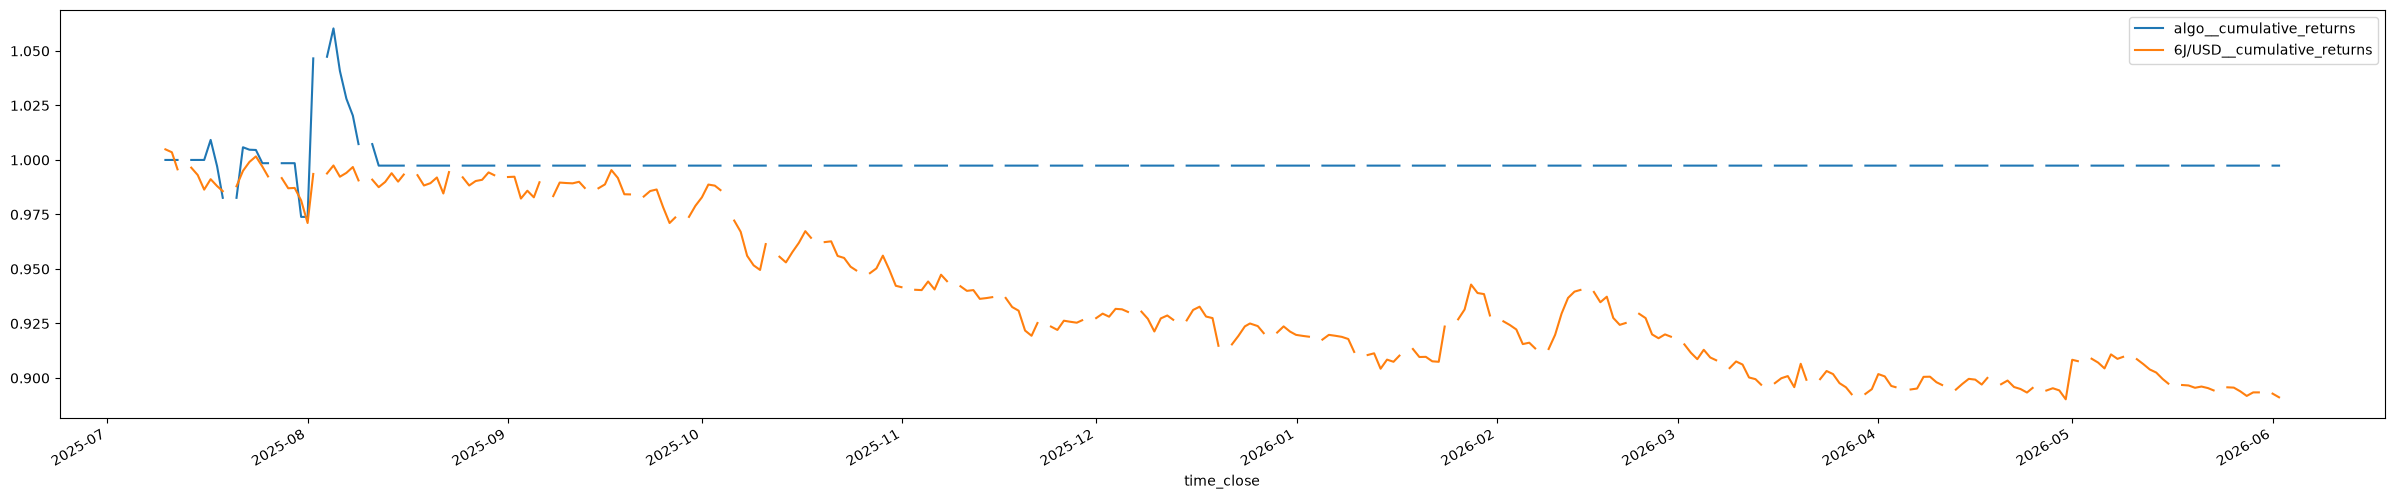

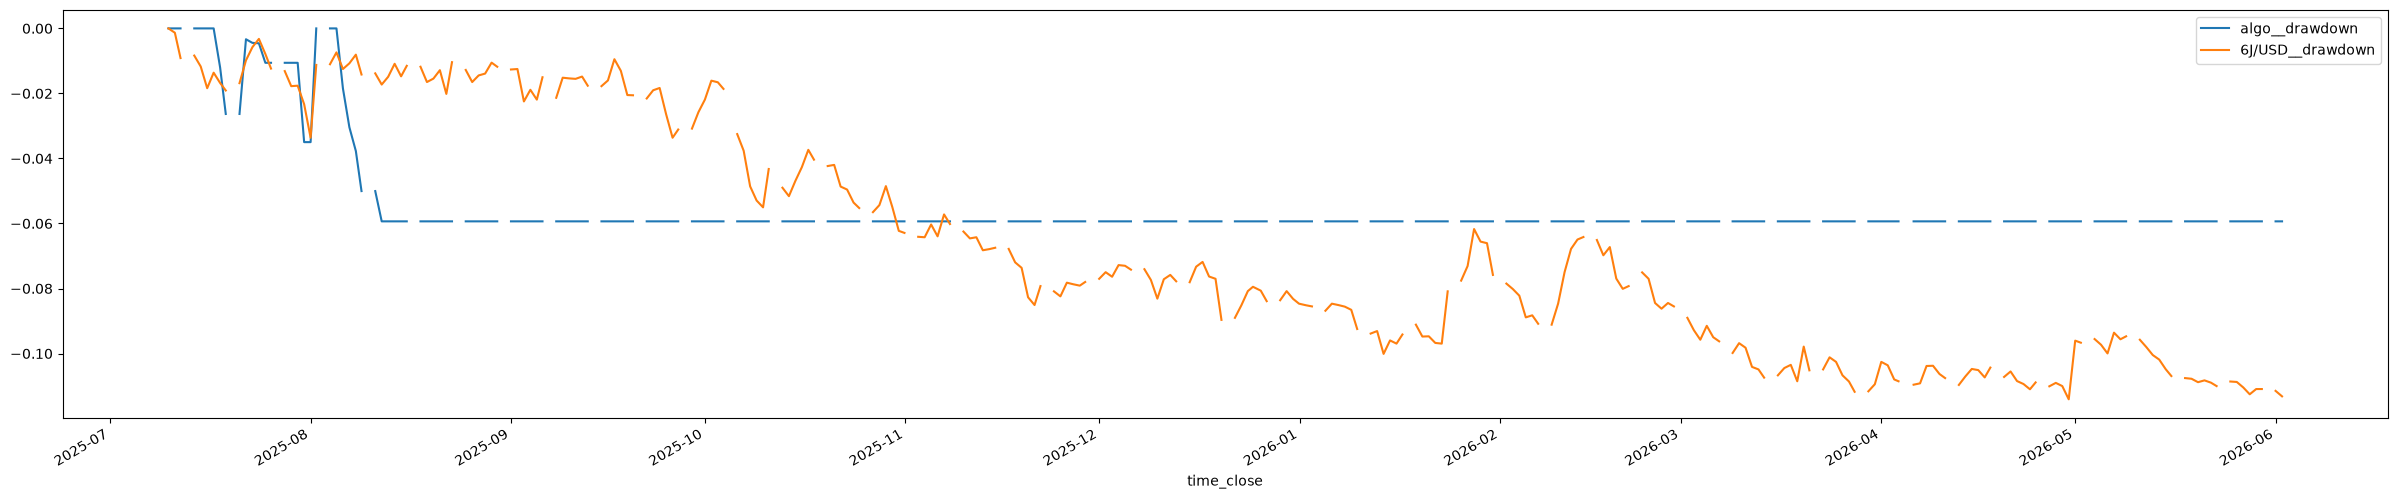

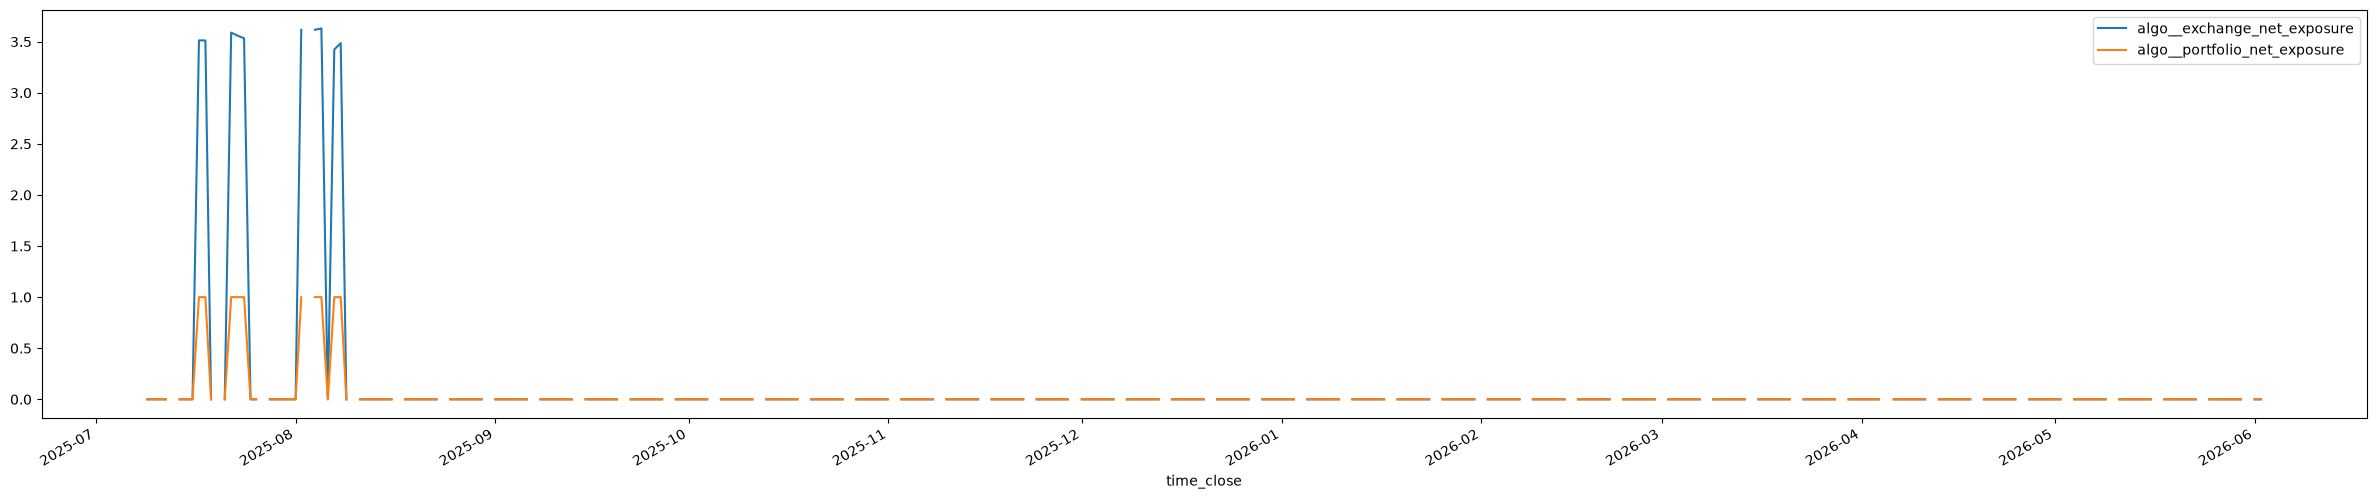

In [6]:

# run only one next step
market.reset()

# Tradeify Growth $50k account: $2,000 (4%) EOD-trailing drawdown, permanently halts
# trading (account_failed) once breached -- see middleware.py / PROP_FIRM_PLAN.md.
# Now also models Tradeify's real lock-once-reached mechanic: the trailing floor
# freezes permanently at initial_balance + $100 the first time EOD balance reaches
# initial_balance * (1 + drawdown_percent) + $100 (e.g. $52,100 for this account),
# rather than continuing to trail upward forever past that point.
drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.04)
# Tradeify's real $1,250/day soft daily-loss pause on a $50k account (2.5% of
# balance): flattens and halts for the rest of the trading day, then resumes
# normally the next day (unlike the drawdown middleware's permanent halt).
# Previously not modeled at all in this pipeline despite being a real,
# already-documented Tradeify rule (PROP_FIRM_PLAN.md).
daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.025)

backtest = Backtester(
    market=market,
    portfolio=portfolio,
    exchange=exchange,
    reporter=reporter,
    middlewares=[daily_loss_middleware, drawdown_middleware],
)
# deposit prop-firm-sized funds so we can trade
backtest.exchange.transactions.add_deposit(asset="USD", volume=50000)
backtest.run_all()

# Print Report
print("Candles Processed: ", backtest.market.current['num'])
print("Account failed (drawdown breach): ", drawdown_middleware.account_failed)
print("Drawdown floor locked (reached profit buffer): ", drawdown_middleware.locked)
# formatted HTML table (description column + color-coded cells) instead of the raw
# numeric DataFrame -- see backtester.performance.report_html for the per-metric rules.
display(HTML(backtest.reporter.summary_html_table()))

if backtest.reporter.merged is not None:
    # Print a chart to compare the returns
    backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns"
        ], figsize=(30,6))

    backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown"
        ], figsize=(30,6))

    backtest.reporter.merged.plot(x="time_close", y=[
        "algo__exchange_net_exposure",
        "algo__portfolio_net_exposure"
        ], figsize=(30,6))


In [7]:
# market.merged
pd.DataFrame(backtest.exchange.get_logs())


,time,message
0,2025-07-08 22:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
1,2025-07-16 14:59:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
2,2025-07-17 05:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
3,2025-07-17 23:59:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
4,2025-07-18 04:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
5,2025-07-18 12:59:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
6,2025-07-18 17:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
7,2025-07-21 00:59:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...
8,2025-07-22 06:59:59.999,Rebalanced: Portfolio Exposure 0.0 | Exchange ...
9,2025-07-22 11:59:59.999,Rebalanced: Portfolio Exposure 1.0 | Exchange ...


In [8]:
# get dataframe with all the trades that were executed
def _trade_to_dict(trade):
    d = trade.__dict__.copy()
    for k, v in d.items():
        if hasattr(v, "value"):
            d[k] = v.value
    return d

pd.DataFrame([_trade_to_dict(t) for t in backtest.reporter.trades])


,symbol,side,time_open,time_close,open_price,close_price,close_reason,pnl,result,holding_period,risk_percent
0,6J/USD,long,1752677999999000000,1752731999999000000,0.007006,0.007001,signal,-0.000642,loser,54000000000000,0.3
1,6J/USD,long,1752796799999000000,1752814799999000000,0.007003,0.006992,signal,-0.001428,loser,18000000000000,0.3
2,6J/USD,long,1752843599999000000,1752861599999000000,0.007006,0.006990,signal,-0.002355,loser,18000000000000,0.3
3,6J/USD,long,1753059599999000000,1753167599999000000,0.007005,0.007031,signal,0.003712,winner,108000000000000,0.3
4,6J/USD,long,1753185599999000000,1753257599999000000,0.007061,0.007082,signal,0.002903,winner,72000000000000,0.3
5,6J/USD,long,1753268399999000000,1753354799999000000,0.007098,0.007088,signal,-0.001550,loser,86400000000000,0.3
6,6J/USD,long,1753837199999000000,1753883999999000000,0.007014,0.006966,signal,-0.006843,loser,46800000000000,0.3
7,6J/USD,long,1754049599999000000,1754384399999000000,0.006896,0.007031,signal,0.019577,winner,334800000000000,0.3
8,6J/USD,long,1754456399999000000,1754470799999000000,0.007042,0.007020,signal,-0.003124,loser,14400000000000,0.3
9,6J/USD,long,1754488799999000000,1754535599999000000,0.007047,0.007028,signal,-0.002696,loser,46800000000000,0.3
